In [1]:
import numpy as np # linear algebra
import math

a = np.array([5.0, 4.0, 2.5, 4.5, 5.9, 2.8, 3.5])
n = 7
m = a.mean()
t = 0
for i in a:
    t += (i - m) * (i - m)
x1 = t / (n - 1)
x2 = t / n
z1 = math.sqrt(x1)
z2 = math.sqrt(x2)
print(z1)
print(z2)
print(x1)
print(x2)

1.2106668764421888
1.1208597283390305
1.4657142857142862
1.2563265306122453


In [2]:
!pip install scanpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install backports
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#sc.logging.print_versions()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 5.5 MB/s eta 0:00:00
  Created wheel for session-info: filename=session_info-1.0.0-py3-none-any.whl size=8023 sha256=a9c0a8a63e1b5ddf131a35eaf1aee3363a1aa11ea4a0ff0469b6d9a3c8f5855a
  Stored in directory: /root/.cache/pip/wheels/6a/aa/b9/eb5d4031476ec10802795b97ccf937b9bd998d68a9b268765a
Successfully built session-info
ERROR: Could not find a version that satisfies the requirement backports (from versions: none)
ERROR: No matching distribution found for backports


In [11]:
adata = sc.datasets.visium_sge(sample_id='Targeted_Visium_Human_OvarianCancer_Pan_Cancer')
#adata = sc.datasets.visium_sge(sample_id='Parent_Visium_Human_OvarianCancer')
#adata = sc.datasets.visium_sge(sample_id='Targeted_Visium_Human_OvarianCancer_Immunology')
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

reading /content/data/Targeted_Visium_Human_OvarianCancer_Pan_Cancer/filtered_feature_bc_matrix.h5
 (0:00:00)


In [12]:
adata

AnnData object with n_obs × n_vars = 3493 × 1253
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

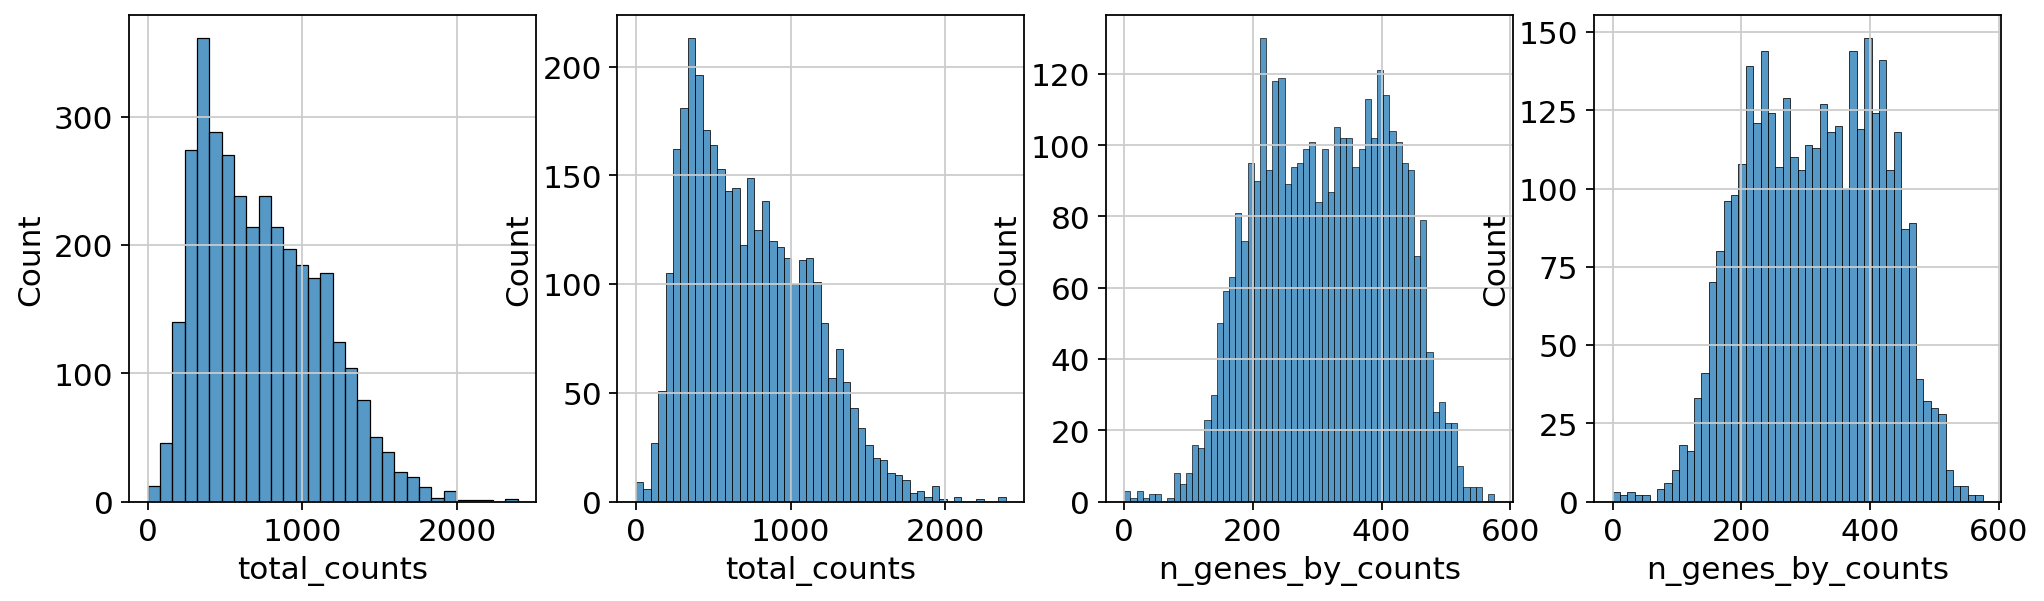

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(
    adata.obs["total_counts"][adata.obs["total_counts"] < 20000],
    kde=False,
    bins=50,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.histplot(
    adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 7000],
    kde=False,
    bins=50,
    ax=axs[3],
)

In [14]:
sc.pp.filter_cells(adata, min_counts=300)
sc.pp.filter_cells(adata, max_counts=2000)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

filtered out 412 cells that have less than 300 counts
filtered out 5 cells that have more than 2000 counts
#cells after MT filter: 3076
filtered out 147 genes that are detected in less than 10 cells


In [15]:
adata

AnnData object with n_obs × n_vars = 3076 × 1106
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

In [16]:
gene_names = adata.var.index
gene_to_check = 'ROR2'
if gene_to_check in gene_names:
    print(f"Gene '{gene_to_check}' is present in the dataset.")
else:
    print(f"Gene '{gene_to_check}' is not present in the dataset.")

Gene 'ROR2' is not present in the dataset.


In [17]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=200)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [18]:
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.0 MB/s eta 0:00:00


computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:42)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)
running Leiden clustering


<ipython-input-19-d4d1f42b530f>:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="clusters")


    finished: found 6 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:01)


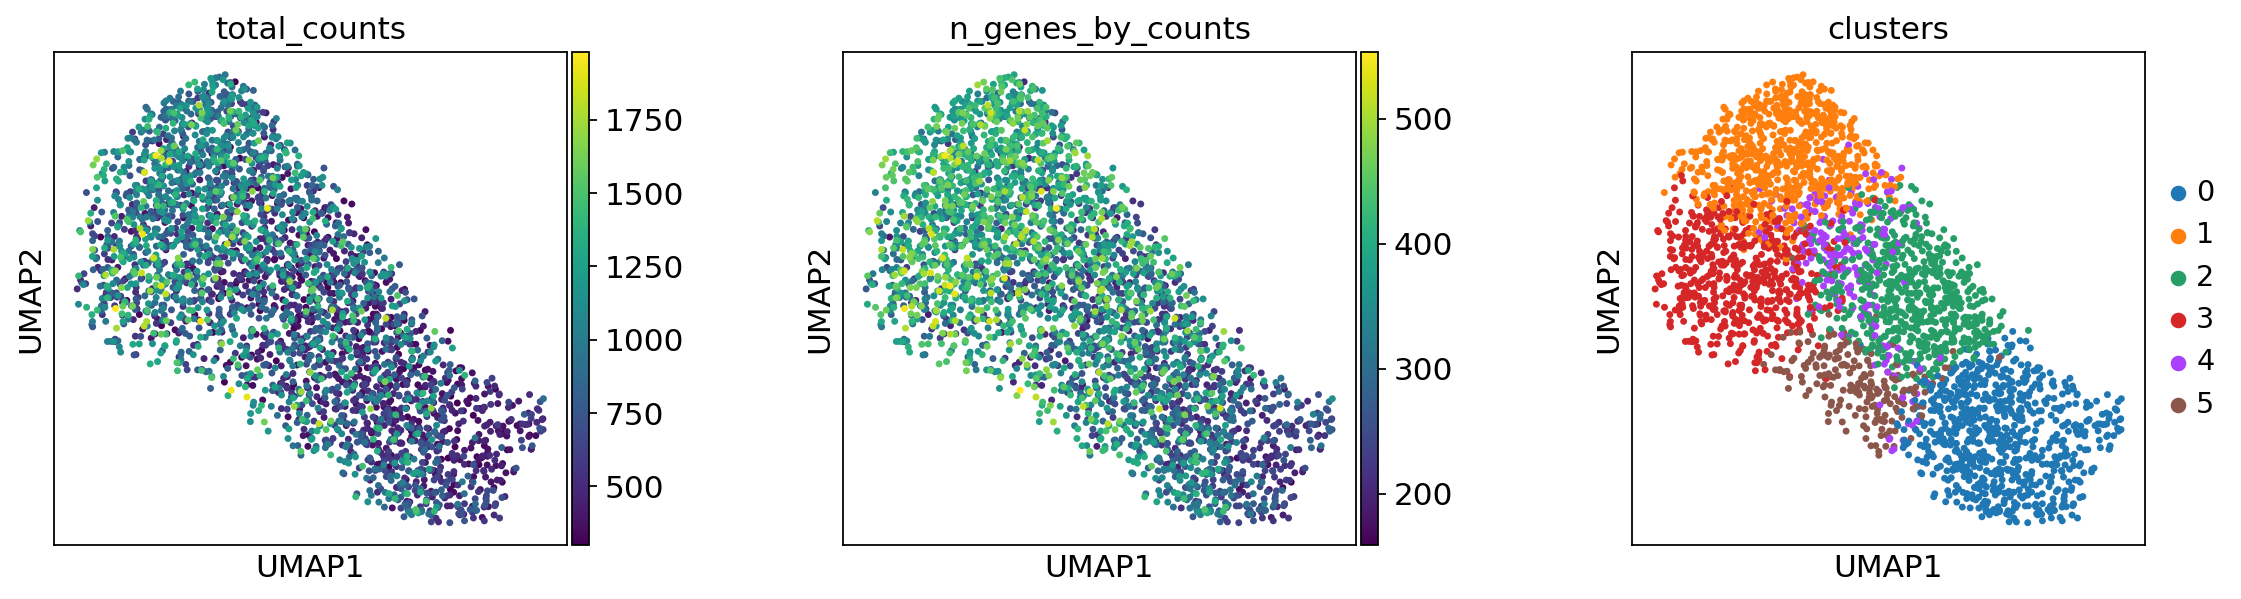

In [19]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="clusters")
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

In [20]:
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts"])

Output hidden; open in https://colab.research.google.com to view.

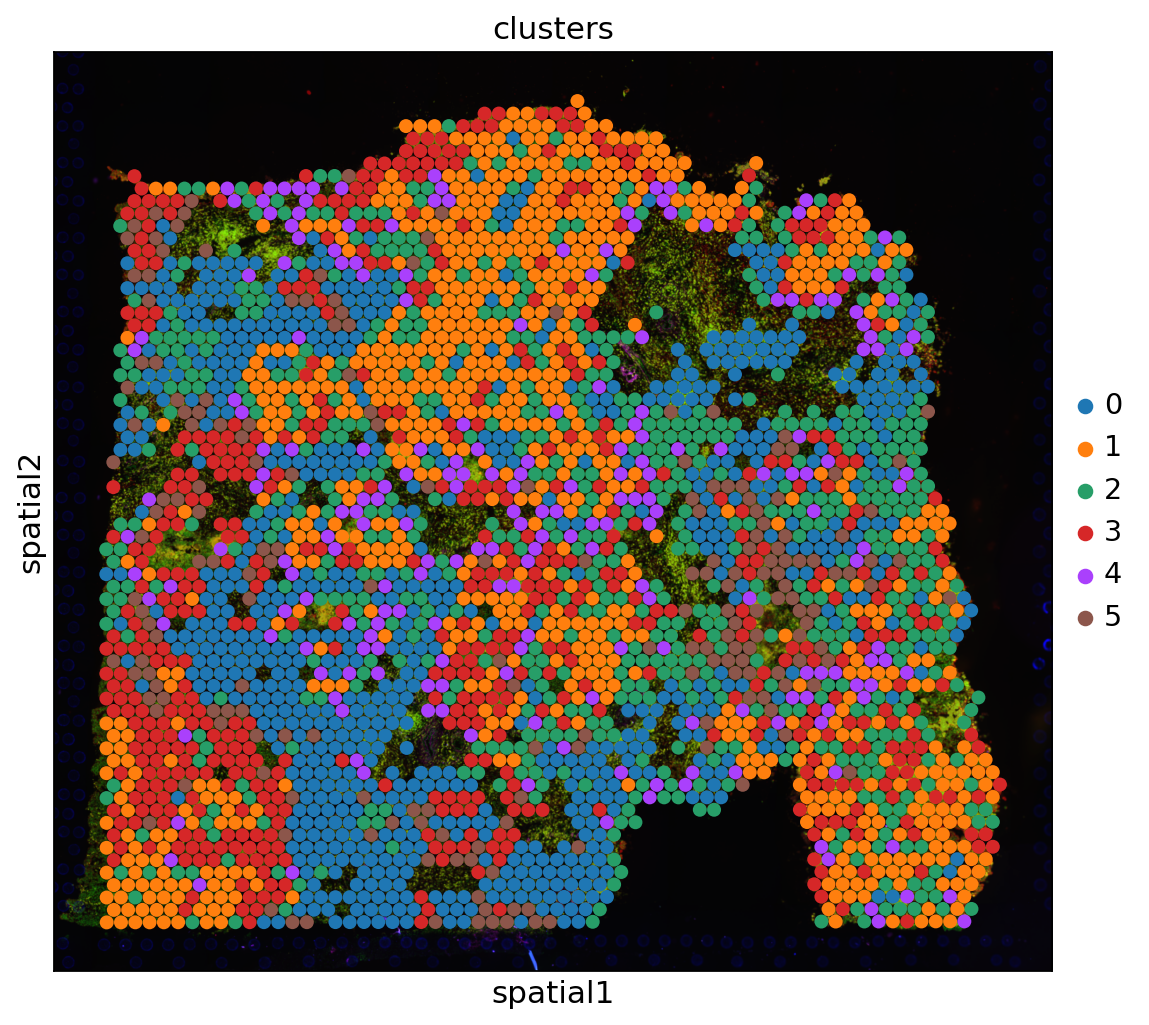

In [21]:
sc.pl.spatial(adata, img_key="hires", color="clusters", size=1.5, alpha=1)

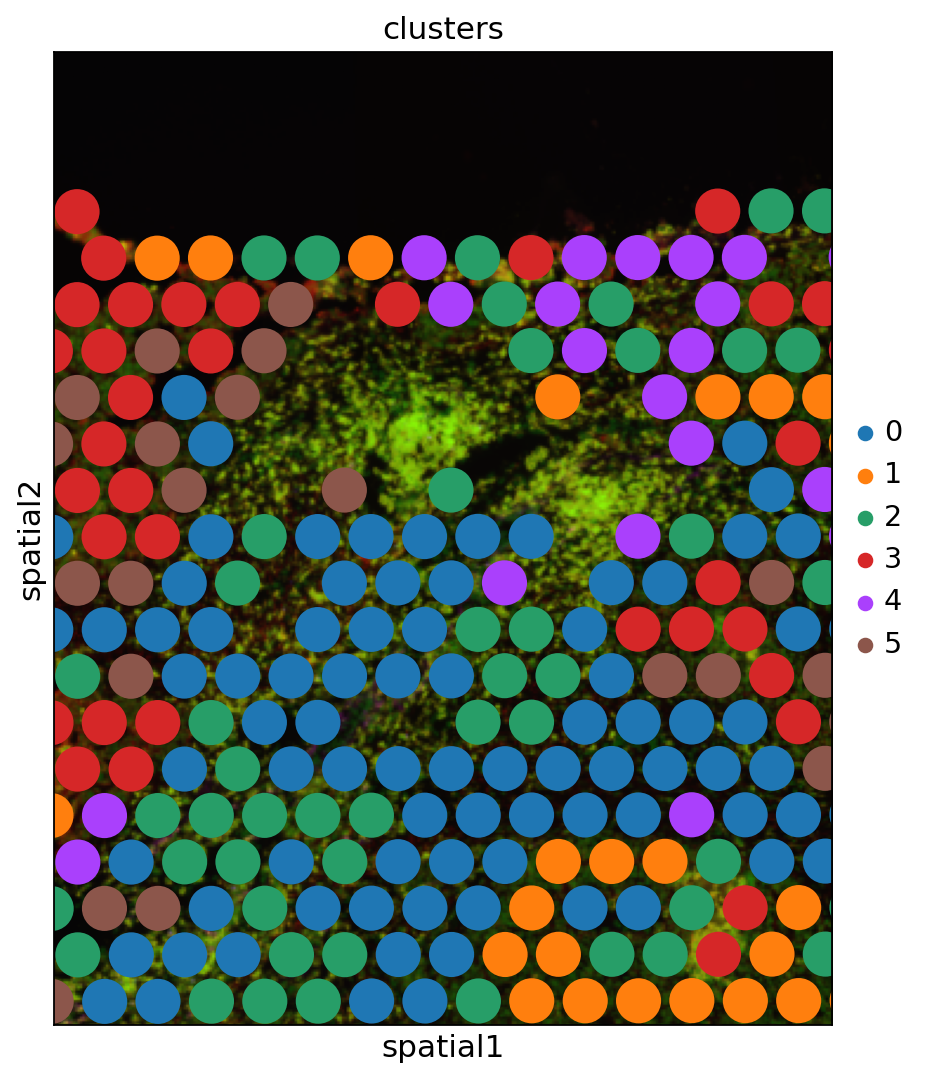

In [22]:
sc.pl.spatial(adata, img_key="hires", color="clusters", crop_coord=[3000, 7000, 5000, 10000],  alpha=1, size=1.3)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_clusters']`


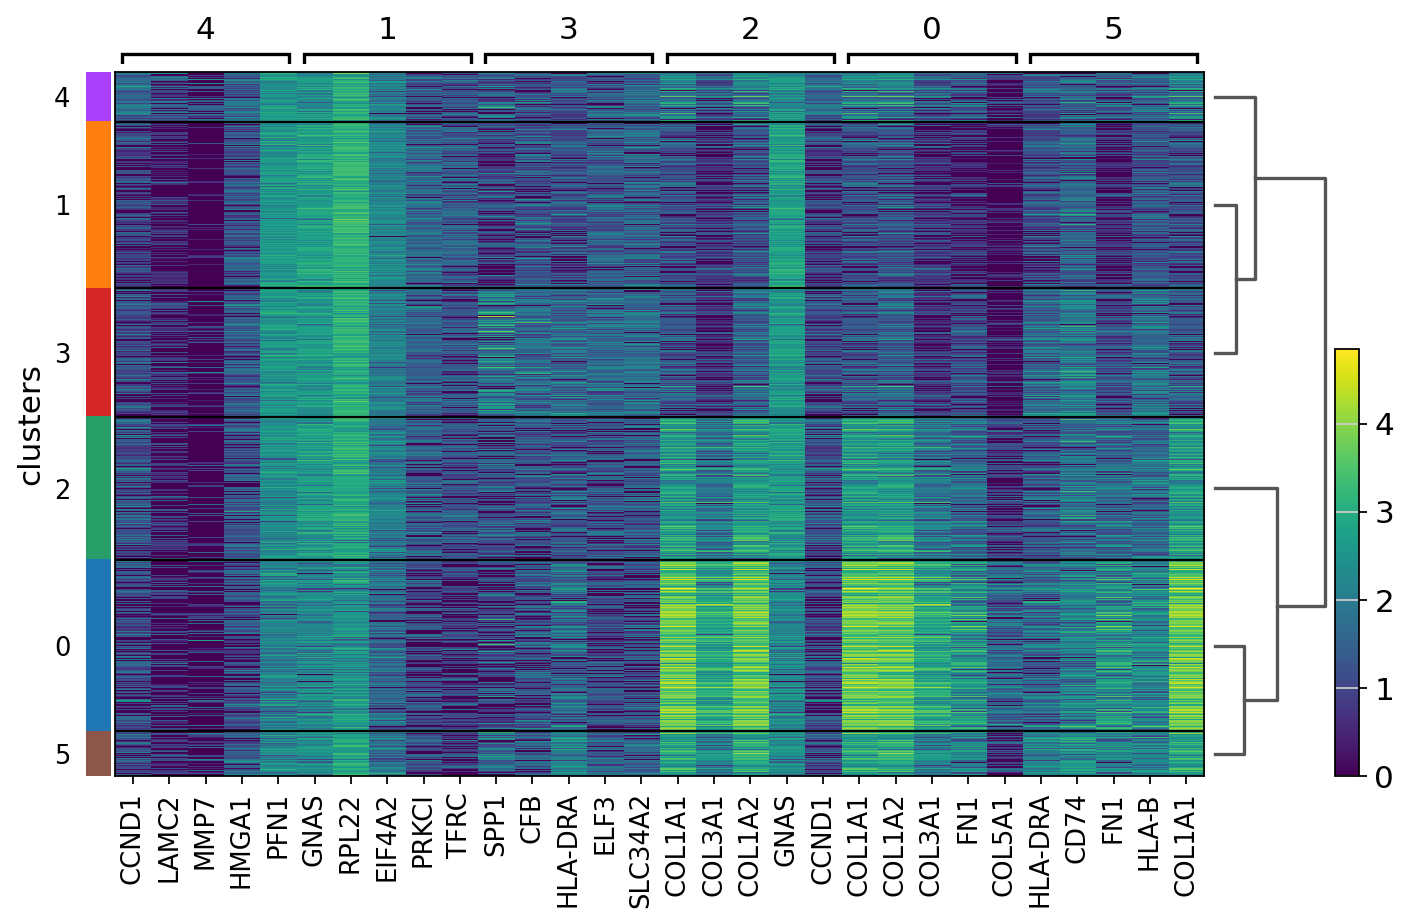

In [23]:
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby="clusters")

In [24]:
sc.pl.spatial(adata, img_key="hires", color=["clusters", "WNT5A", "PDGFRA", "PDGFRB", "PDGFA", "PDGFB"])

Output hidden; open in https://colab.research.google.com to view.

In [27]:
gene_of_interest = ["WNT5A", "PDGFRA", "PDGFRB", "PDGFA", "PDGFB"]


# Extract expression data for the gene (convert to dense if sparse)
gene_expression = adata[:, gene_of_interest].X.toarray().flatten() if isinstance(adata[:, gene_of_interest].X, np.matrix) else np.array(adata[:, gene_of_interest].X).flatten()

# Identify high-expression spots (adjust threshold as needed)
high_expression_spots = gene_expression > np.mean(gene_expression)

# Subset the adata object to high-expression spots
adata_high_expr = adata[high_expression_spots, :]

# Count clusters in high-expression regions
cluster_counts = adata_high_expr.obs['leiden'].value_counts()
print(cluster_counts)



ValueError: setting an array element with a sequence.

In [ ]:
sc.pl.spatial(adata, img_key="hires", color=["clusters", "FZD2", "FZD3", "FZD7", "FZD8", "FZD10"])

In [ ]:
sc.pl.spatial(adata, img_key="hires", color=["clusters", "NOTCH2", "NOTCH3", "HES1", "clusters", "JUN", "ETS1"])

In [ ]:
!pip install spatialde

In [ ]:
import SpatialDE